---
date: "2026-08-31"
date-modified: last-modified
format:
  html:
    toc: true
---



# Deep Neural Networks

Deep neural networks represent a fundamental class of expressive, non-linear function approximators. At their mathematical core, feedforward neural networks are parameterized compositions of alternating affine transformations and element-wise non-linear activation functions. Rather than acting as mysterious black boxes, their expressivity arises directly from the geometric folding and partitioning of Euclidean space into piecewise linear regions.

This note establishes the formal mathematical foundations of feedforward deep architectures, analyzes their representational capacity, derives the geometry of Continuous Piecewise Linear (CPWL) manifolds under ReLU activations, and visualizes layer-by-layer latent transformations.

---

## 1\. Mathematical Formulation of Feedforward Networks

Let $\mathbf{x} \in \mathbb{R}^{D_0}$ denote an input feature vector in a $D_0$-dimensional Euclidean domain. A feedforward deep neural network consisting of $K$ hidden layers maps $\mathbf{x}$ to an output vector $\mathbf{y} \in \mathbb{R}^{D_{K+1}}$ through a sequence of intermediate layer representations.

::: {#def-feedforward-network}
## Feedforward Deep Neural Network
Let $K \in \mathbb{N}$ denote the depth (number of hidden layers) of the network. For each layer $k \in \{1, 2, \dots, K\}$ with hidden dimension $D_k \in \mathbb{N}$:

* **Weight Matrix:** $\boldsymbol{\Omega}_k \in \mathbb{R}^{D_k \times D_{k-1}}$
* **Bias Vector:** $\boldsymbol{\beta}_k \in \mathbb{R}^{D_k}$
* **Activation Function:** $a: \mathbb{R} \to \mathbb{R}$, applied element-wise.

Let $\mathbf{h}_0 \equiv \mathbf{x} \in \mathbb{R}^{D_0}$ denote the input. The forward propagation recurrence relation is defined by:

$$
\begin{aligned}
\mathbf{f}_k &= \boldsymbol{\Omega}_k \mathbf{h}_{k-1} + \boldsymbol{\beta}_k \quad &&\text{(Pre-activations)} \\
\mathbf{h}_k &= a[\mathbf{f}_k] \quad &&\text{(Hidden layer activations)}
\end{aligned}
$$

for $k = 1, 2, \dots, K$. The final network output $\mathbf{y} \equiv \mathbf{f}[\mathbf{x}, \boldsymbol{\phi}] \in \mathbb{R}^{D_{K+1}}$ is given by a final affine transformation:

$$
\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}] = \boldsymbol{\Omega}_{K+1} \mathbf{h}_K + \boldsymbol{\beta}_{K+1}
$$

The complete parameter tuple $\boldsymbol{\phi}$ collects all network weights and biases:

$$
\boldsymbol{\phi} = \left\{ \boldsymbol{\Omega}_1, \boldsymbol{\beta}_1, \boldsymbol{\Omega}_2, \boldsymbol{\beta}_2, \dots, \boldsymbol{\Omega}_{K+1}, \boldsymbol{\beta}_{K+1} \right\}
$$
:::

### 1.1\. Parameter Count and Dimensional Analysis

The total number of scalar parameters $\dim(\boldsymbol{\phi})$ in a fully connected feedforward architecture with layer widths $D_0, D_1, \dots, D_{K+1}$ is:

$$
\dim(\boldsymbol{\phi}) = \sum_{k=1}^{K+1} \left( D_k D_{k-1} + D_k \right) = \sum_{k=1}^{K+1} D_k (D_{k-1} + 1)
$$

| Layer Index | Input Dimension | Output Dimension | Weight Matrix Shape | Bias Shape | Parameter Count |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Layer 1** | $D_0$ | $D_1$ | $D_1 \times D_0$ | $D_1 \times 1$ | $D_1(D_0 + 1)$ |
| **Layer $k$** | $D_{k-1}$ | $D_k$ | $D_k \times D_{k-1}$ | $D_k \times 1$ | $D_k(D_{k-1} + 1)$ |
| **Output Layer** | $D_K$ | $D_{K+1}$ | $D_{K+1} \times D_K$ | $D_{K+1} \times 1$ | $D_{K+1}(D_K + 1)$ |



## 2\. Activation Functions and the Necessity of Non-Linearity

Without non-linear activation functions between layers, stacking linear transformations provides zero increase in expressive power.

::: {#prp-collapse-linear-networks}
## Collapse of Purely Linear Multilayer Networks
Let $\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$ be a $K$-layer neural network where the activation function is the identity mapping $a[z] = z$. Then $\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$ is mathematically equivalent to a single affine transformation:

$$
\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}] = \tilde{\boldsymbol{\Omega}} \mathbf{x} + \tilde{\boldsymbol{\beta}}
$$

where $\tilde{\boldsymbol{\Omega}} = \prod_{j=K+1}^1 \boldsymbol{\Omega}_j$ and $\tilde{\boldsymbol{\beta}} \in \mathbb{R}^{D_{K+1}}$.
:::

::: {.callout-tip collapse="true"}
## Proof of Proposition: Collapse of Linear Multilayer Networks
We prove by induction on layer depth $K$.

**Base Step ($K=1$):**
With $a[z] = z$, the hidden activation is $\mathbf{h}_1 = \mathbf{f}_1 = \boldsymbol{\Omega}_1 \mathbf{x} + \boldsymbol{\beta}_1$. The output is:
$$
\mathbf{y} = \boldsymbol{\Omega}_2 \mathbf{h}_1 + \boldsymbol{\beta}_2 = \boldsymbol{\Omega}_2 (\boldsymbol{\Omega}_1 \mathbf{x} + \boldsymbol{\beta}_1) + \boldsymbol{\beta}_2 = (\boldsymbol{\Omega}_2 \boldsymbol{\Omega}_1) \mathbf{x} + (\boldsymbol{\Omega}_2 \boldsymbol{\beta}_1 + \boldsymbol{\beta}_2)
$$
Setting $\tilde{\boldsymbol{\Omega}} = \boldsymbol{\Omega}_2 \boldsymbol{\Omega}_1$ and $\tilde{\boldsymbol{\beta}} = \boldsymbol{\Omega}_2 \boldsymbol{\beta}_1 + \boldsymbol{\beta}_2$, the output is an affine map.

**Induction Step:**
Assume that for depth $K-1$, the intermediate representation $\mathbf{h}_{K-1}$ is an affine map $\mathbf{h}_{K-1} = \mathbf{A}_{K-1} \mathbf{x} + \mathbf{b}_{K-1}$. For depth $K$:
$$
\mathbf{h}_K = \boldsymbol{\Omega}_K \mathbf{h}_{K-1} + \boldsymbol{\beta}_K = \boldsymbol{\Omega}_K (\mathbf{A}_{K-1} \mathbf{x} + \mathbf{b}_{K-1}) + \boldsymbol{\beta}_K = (\boldsymbol{\Omega}_K \mathbf{A}_{K-1}) \mathbf{x} + (\boldsymbol{\Omega}_K \mathbf{b}_{K-1} + \boldsymbol{\beta}_K)
$$
which is affine. The final output $\mathbf{y} = \boldsymbol{\Omega}_{K+1} \mathbf{h}_K + \boldsymbol{\beta}_{K+1}$ is therefore a composition of affine functions:
$$
\mathbf{y} = (\boldsymbol{\Omega}_{K+1} \boldsymbol{\Omega}_K \cdots \boldsymbol{\Omega}_1) \mathbf{x} + \sum_{k=1}^{K+1} \left( \prod_{j=K+1}^{k+1} \boldsymbol{\Omega}_j \right) \boldsymbol{\beta}_k
$$
Defining $\tilde{\boldsymbol{\Omega}} = \boldsymbol{\Omega}_{K+1} \boldsymbol{\Omega}_K \cdots \boldsymbol{\Omega}_1$ and $\tilde{\boldsymbol{\beta}} = \sum_{k=1}^{K+1} \left( \prod_{j=K+1}^{k+1} \boldsymbol{\Omega}_j \right) \boldsymbol{\beta}_k$ completes the proof. $\blacksquare$
:::

### 2.1\. Standard Non-Linear Activation Families

To overcome linear collapse, non-linear activation functions $a[z]$ are introduced:

1. **Rectified Linear Unit (ReLU):**
   $$
   a[z] = \max(0, z) = \begin{cases} z & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases}
   $$
2. **Leaky ReLU:**
   $$
   a[z] = \max(\alpha z, z) \quad \text{with } \alpha \in (0, 1)
   $$
3. **Gaussian Error Linear Unit (GeLU):**
   $$
   a[z] = z \Phi(z) = z P(Z \le z) \quad \text{where } Z \sim \mathcal{N}(0, 1)
   $$
4. **Logistic Sigmoid:**
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)
   $$
5. **Hyperbolic Tangent:**
   $$
   \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} \in (-1, 1)
   $$

::: {.callout-note}
## Intuition: Activation Functions as Coordinate Folding
An activation function transforms space non-uniformly. For example, the ReLU activation acts as a half-space projection: it leaves the positive half-space untouched while folding the negative half-space onto the boundary hyperplane $z = 0$. Stacking these folds across multiple layers allows deep networks to construct intricate decision boundaries.
:::



## 3\. Geometry of Deep ReLU Networks: Continuous Piecewise Linear Functions

When ReLU activations are used, the resulting network function possesses rich geometric structure: it belongs to the family of **Continuous Piecewise Linear (CPWL)** functions.

::: {#thm-cpwl-networks}
## CPWL Characterization of ReLU Networks
Every feedforward neural network $\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$ with ReLU activation functions computes a continuous piecewise linear function. Specifically, there exists a partition of the input domain $\mathbb{R}^{D_0}$ into a finite set of convex polyhedral regions $\{\mathcal{R}_m\}_{m=1}^M$ such that for every $\mathbf{x} \in \mathcal{R}_m$:

$$
\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}] = \mathbf{A}_m \mathbf{x} + \mathbf{b}_m
$$

where $\mathbf{A}_m \in \mathbb{R}^{D_{K+1} \times D_0}$ and $\mathbf{b}_m \in \mathbb{R}^{D_{K+1}}$ are constant within region $\mathcal{R}_m$.
:::

::: {.callout-tip collapse="true"}
## Proof of Theorem: CPWL Characterization
We prove that the class of CPWL functions is closed under affine transformation, composition, and element-wise maximum operations.

1. **Closure under Affine Composition:** Let $g: \mathbb{R}^{D_{k-1}} \to \mathbb{R}^{D_k}$ be a CPWL function with polyhedral partition $\mathcal{P}_1$. For any affine map $T(\mathbf{u}) = \mathbf{W}\mathbf{u} + \mathbf{c}$, the composition $T(g(\mathbf{x}))$ is piecewise linear over the same partition $\mathcal{P}_1$, and continuity is preserved since the composition of continuous functions is continuous.
2. **Closure under ReLU:** The ReLU operation $\text{ReLU}(u) = \max(0, u)$ is continuous and piecewise linear on $\mathbb{R}$ with a single knot at $u = 0$. For any affine pre-activation $f_{k,j}(\mathbf{x}) = \boldsymbol{\omega}_{k,j}^T \mathbf{h}_{k-1}(\mathbf{x}) + \beta_{k,j}$, the zero level-set $\{\mathbf{x} \mid f_{k,j}(\mathbf{x}) = 0\}$ defines a hyperplane dividing each polyhedral region into two sub-polyhedra. On each sub-polyhedron, $\text{ReLU}(f_{k,j}(\mathbf{x}))$ is purely affine.
3. **Induction on Depth:** At layer $k=1$, pre-activations are affine, and ReLUs partition $\mathbb{R}^{D_0}$ into convex polytopes bounded by $D_1$ hyperplanes. Assuming $\mathbf{h}_{k-1}(\mathbf{x})$ is CPWL over a polyhedral partition, layer $k$ introduces additional hyperplanes that further subdivide these polyhedra while remaining CPWL.
4. By induction, the entire composition $\mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$ is continuous and piecewise linear across the final intersected convex polyhedral partition $\{\mathcal{R}_m\}$. $\blacksquare$
:::

### 3.1\. Expressive Power: Linear Regions Bound

A key theoretical advantage of depth over width is the number of linear regions the network can generate.

::: {#prp-linear-regions-bound}
## Bound on the Number of Linear Regions (Montúfar et al., 2014)
For a deep ReLU network with input dimension $D_0$, depth $K$, and hidden width $D_k = D \ge D_0$ for all $k \in \{1, \dots, K\}$, the maximal number of linear regions $\mathcal{N}_{\text{regions}}$ satisfies:

$$
\mathcal{N}_{\text{regions}} \ge \left( \left\lfloor \frac{D}{D_0} \right\rfloor \right)^{(K-1)D_0} \sum_{j=0}^{D_0} \binom{D}{j} = \Omega\left( \left( \frac{D}{D_0} \right)^{(K-1)D_0} D^{D_0} \right)
$$
:::

In contrast, a shallow network ($K=1$) with the same total number of parameters can only generate $\mathcal{O}(D^{D_0})$ linear regions. Depth enables **exponential growth in the number of linear regions** with respect to the number of parameters.



## 4\. Universal Approximation Theorem

::: {#thm-universal-approximation}
## Universal Approximation Theorem (Cybenko, 1989; Hornik, 1991)
Let $\sigma: \mathbb{R} \to \mathbb{R}$ be any non-constant, bounded, and continuous activation function. Let $K \subset \mathbb{R}^{D_0}$ be a [compact set](compactness.ipynb). For any continuous function $f \in C(K)$ and any tolerance $\varepsilon > 0$, there exists a finite integer $M \in \mathbb{N}$, weights $\mathbf{w}_j \in \mathbb{R}^{D_0}$, biases $b_j \in \mathbb{R}$, and output coefficients $v_j \in \mathbb{R}$ such that the single-hidden-layer network:

$$
\hat{f}(\mathbf{x}) = \sum_{j=1}^M v_j \sigma\left( \mathbf{w}_j^T \mathbf{x} + b_j \right)
$$

satisfies:

$$
\sup_{\mathbf{x} \in K} |f(\mathbf{x}) - \hat{f}(\mathbf{x})| < \varepsilon
$$
:::

::: {.callout-note}
## Intuition: The Gap Between Theory and Optimization
While the Universal Approximation Theorem guarantees that a sufficiently wide single-hidden-layer network can approximate any continuous function, it does not guarantee that gradient descent can efficiently discover such parameters, nor that the required width $M$ remains computationally feasible. Deep networks introduce hierarchical compositional priors that enable efficient learning of structured real-world data with dramatically fewer parameters.
:::

---

## 5\. Layer-by-Layer Representation Learning & Manifold Untangling

Each hidden layer $\mathbf{h}_k = a[\boldsymbol{\Omega}_k \mathbf{h}_{k-1} + \boldsymbol{\beta}_k]$ maps the representation space $\mathcal{H}_{k-1}$ to a new latent coordinate space $\mathcal{H}_k$.

1. **Affine Transformation ($\boldsymbol{\Omega}_k \mathbf{h}_{k-1} + \boldsymbol{\beta}_k$):** Rotates, shears, scales, and shifts data points in Euclidean space.
2. **Non-Linear Activation ($a[\cdot]$):** Collapses or folds regions of the coordinate system along hyperplane boundaries.

Through successive alternating transformations, deeply entangled manifolds (such as concentric circles or interleaved spirals) that are impossible to separate linearly in the input space $\mathbb{R}^{D_0}$ become **linearly separable** in the final latent space $\mathbf{h}_K \in \mathbb{R}^{D_K}$.



## 6\. PyTorch Implementation & Layer Output Visualizations

We implement a modular feedforward deep neural network in PyTorch and inspect:
1. Approximation of a 1D function demonstrating piecewise linear activation joints.
2. 2D decision boundary formation and linear region decomposition.
3. Layer-by-layer manifold untangling on a non-linearly separable dataset.


Executing on device: cuda


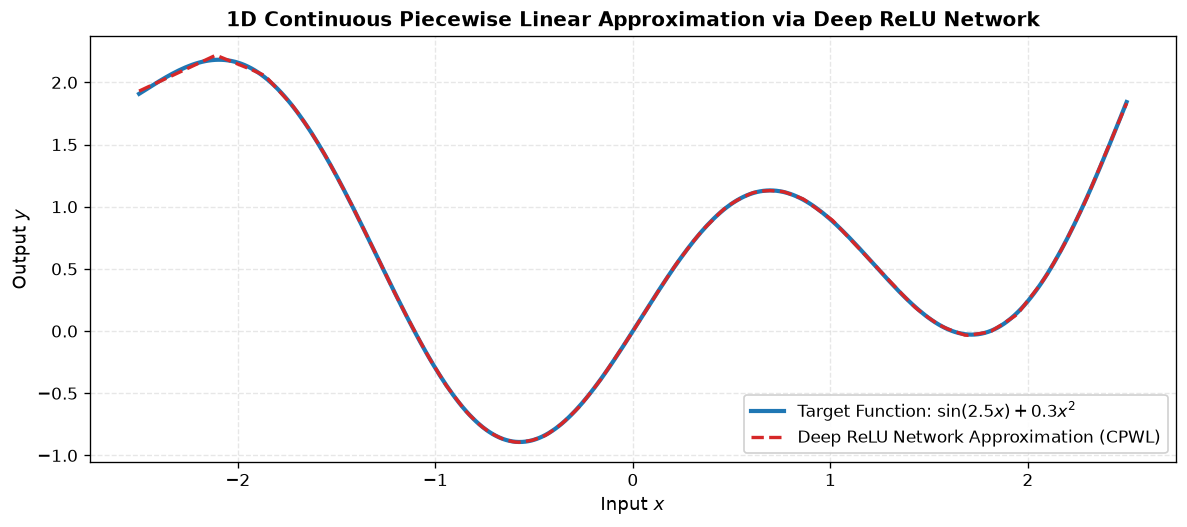

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set seeds for deterministic reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select GPU if available, fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

# Define a Deep Feedforward Network with intermediate layer extraction
class DeepFeedForward(nn.Module):
    def __init__(self, layer_dims, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.ModuleList()
        self.activation = activation()
        for i in range(len(layer_dims) - 1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            
    def forward(self, x):
        activations = [x]
        h = x
        for i, layer in enumerate(self.layers[:-1]):
            h = self.activation(layer(h))
            activations.append(h)
        # Final output layer (linear)
        out = self.layers[-1](h)
        activations.append(out)
        return out, activations

# -------------------------------------------------------------
# Experiment 1: 1D Continuous Piecewise Linear Function Fitting
# -------------------------------------------------------------
x_1d = torch.linspace(-2.5, 2.5, 300).unsqueeze(1).to(device)
y_1d = torch.sin(2.5 * x_1d) + 0.3 * x_1d**2

model_1d = DeepFeedForward([1, 64, 64, 1]).to(device)
optimizer = optim.Adam(model_1d.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(1200):
    optimizer.zero_grad()
    pred, _ = model_1d(x_1d)
    loss = criterion(pred, y_1d)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred, acts = model_1d(x_1d)
    x_np = x_1d.cpu().numpy()
    y_np = y_1d.cpu().numpy()
    pred_np = y_pred.cpu().numpy()

# Plot 1D approximation showing CPWL behavior
plt.figure(figsize=(10, 4.5), dpi=120)
plt.plot(x_np, y_np, label=r'Target Function: $\sin(2.5x) + 0.3x^2$', color='#1f77b4', lw=2.5)
plt.plot(x_np, pred_np, label='Deep ReLU Network Approximation (CPWL)', color='#d62728', linestyle='--', lw=2)
plt.title('1D Continuous Piecewise Linear Approximation via Deep ReLU Network', fontsize=12, fontweight='bold')
plt.xlabel('Input $x$', fontsize=11)
plt.ylabel('Output $y$', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


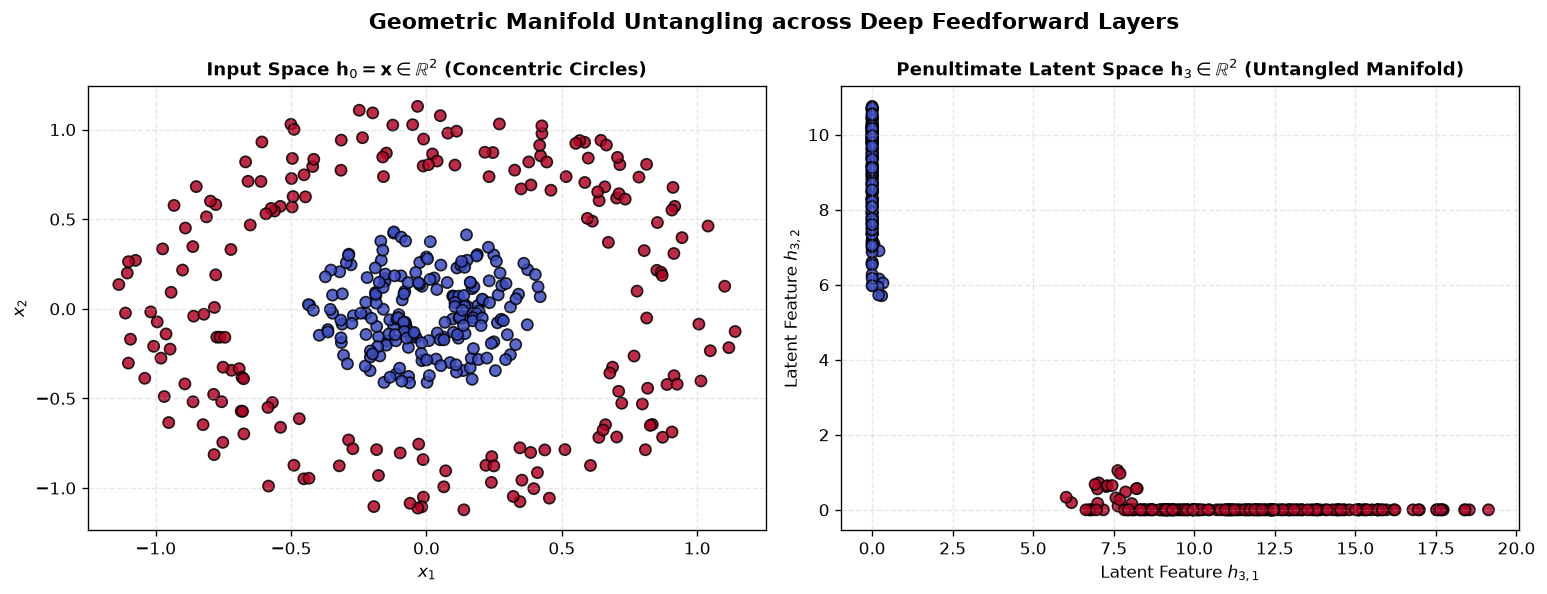

In [2]:
# -------------------------------------------------------------
# Experiment 2: Manifold Untangling & Layer Representation Inspection
# -------------------------------------------------------------
# Generate Concentric Circles Dataset
N = 400
radii_inner = np.random.uniform(0.1, 0.45, N // 2)
theta_inner = np.random.uniform(0, 2*np.pi, N // 2)
X_inner = np.stack([radii_inner * np.cos(theta_inner), radii_inner * np.sin(theta_inner)], axis=1)

radii_outer = np.random.uniform(0.75, 1.15, N // 2)
theta_outer = np.random.uniform(0, 2*np.pi, N // 2)
X_outer = np.stack([radii_outer * np.cos(theta_outer), radii_outer * np.sin(theta_outer)], axis=1)

X_data = np.vstack([X_inner, X_outer])
y_data = np.hstack([np.zeros(N // 2), np.ones(N // 2)])

X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1).to(device)

# Deep Classifier [2 -> 16 -> 8 -> 2 -> 1]
clf = DeepFeedForward([2, 16, 8, 2, 1]).to(device)
opt_clf = optim.Adam(clf.parameters(), lr=0.015)
bce_loss = nn.BCEWithLogitsLoss()

for epoch in range(1500):
    opt_clf.zero_grad()
    logits, _ = clf(X_tensor)
    loss = bce_loss(logits, y_tensor)
    loss.backward()
    opt_clf.step()

with torch.no_grad():
    _, activations = clf(X_tensor)
    h0 = activations[0].cpu().numpy()  # Input Space (2D)
    h3 = activations[3].cpu().numpy()  # Penultimate Latent Space (2D)

# Visualize transformation from input space to penultimate latent space
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# Input Space (Non-linearly separable)
scatter0 = axes[0].scatter(h0[:, 0], h0[:, 1], c=y_data, cmap='coolwarm', edgecolors='k', s=45, alpha=0.85)
axes[0].set_title(r"Input Space $\mathbf{h}_0 = \mathbf{x} \in \mathbb{R}^2$ (Concentric Circles)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("$x_1$", fontsize=10)
axes[0].set_ylabel("$x_2$", fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Penultimate Representation Space (Linearly separable!)
scatter1 = axes[1].scatter(h3[:, 0], h3[:, 1], c=y_data, cmap='coolwarm', edgecolors='k', s=45, alpha=0.85)
axes[1].set_title(r"Penultimate Latent Space $\mathbf{h}_3 \in \mathbb{R}^2$ (Untangled Manifold)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Latent Feature $h_{3,1}$", fontsize=10)
axes[1].set_ylabel("Latent Feature $h_{3,2}$", fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Geometric Manifold Untangling across Deep Feedforward Layers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

> **References & Acknowledgments:**
> 
> * Prince, Simon J.D. *Understanding Deep Learning*, MIT Press, 2023. Chapters 3 & 4.
> * Cybenko, George. "Approximation by superpositions of a sigmoidal function." *Mathematics of Control, Signals and Systems* 2.4 (1989): 303-314.
> * Hornik, Kurt. "Approximation capabilities of multilayer feedforward networks." *Neural Networks* 4.2 (1991): 251-257.
> * Montúfar, Guido F., Razvan Pascanu, Kyunghyun Cho, and Yoshua Bengio. "On the number of linear regions of deep neural networks." *Advances in Neural Information Processing Systems (NeurIPS)* 27 (2014).
